# View generated showers

Reads the files written by `python generate.py` (or `jobs/generate.sub`)
and plots them. Needs only numpy and matplotlib.

Each `shower_NNNNN.npz` lists the lit 2 cm voxels: `xyz` [m], `nphotons`, `ijk`, `box_m`.
Set `SHOWER_DIR` below and run all cells.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

SHOWER_DIR = Path("showers")   # folder with shower_*.npz  <-- change this
N_DETAIL = 3                      # showers drawn in full detail
MAX_POINTS_3D = 20000             # brightest voxels kept in the 3D views
CMAP = "Blues"

files = sorted(SHOWER_DIR.glob("shower_*.npz"))
print(f"{len(files)} showers in {SHOWER_DIR.resolve()}")
if (SHOWER_DIR / "run.json").exists():
    print(json.loads((SHOWER_DIR / "run.json").read_text()))

10 showers in /mnt/ceph1-npx/user/qwang/github/corsika_cherenkov_generator/showers
{'model': '/mnt/ceph1-npx/user/qwang/github/corsika_cherenkov_generator/trained_model', 'seed': 0, 'steps': {'ae': 15000, 'attr': 60000, 'dit': 100000, 'struct': 40000}, 't2': True}


## Summary

In [2]:
def load(path):
    s = np.load(path)
    return dict(name=path.stem, xyz=s["xyz"], q=s["nphotons"], ijk=s["ijk"], box=s["box_m"])

showers = [load(f) for f in files]
print(f"{'file':<14}{'voxels':>9}{'photons':>12}{'max/voxel':>11}   extent x, y, z [m]")
for s in showers:
    ext = s["xyz"].max(0) - s["xyz"].min(0)
    print(f"{s['name']:<14}{len(s['q']):>9}{s['q'].sum():>12.3g}{s['q'].max():>11.3g}   "
          + ", ".join(f"{e:.2f}" for e in ext))

file             voxels     photons  max/voxel   extent x, y, z [m]
shower_00000      66322    1.22e+08   1.17e+05   3.85, 3.95, 3.60
shower_00001      38391    9.77e+07   1.38e+05   3.47, 3.84, 3.58
shower_00002      39882    6.32e+07   7.16e+04   3.87, 3.72, 3.59
shower_00003      22777    4.72e+07   7.09e+04   3.60, 3.42, 3.58
shower_00004      36371    9.53e+07   1.64e+05   3.60, 3.84, 3.59
shower_00005      36060    9.29e+07    1.4e+05   3.46, 3.81, 3.59
shower_00006      38537    8.15e+07   1.07e+05   3.60, 3.49, 3.59
shower_00007      53147    6.81e+07    3.7e+04   3.94, 3.81, 3.59
shower_00008      35822    3.93e+07   2.22e+04   3.89, 3.45, 3.59
shower_00009      49365     7.2e+07   5.37e+04   3.85, 3.95, 3.59


## One shower in detail

Top: photon-weighted projections on the three planes (log colour scale, one bin = one voxel).
Bottom: 3D view of the brightest voxels, photons per voxel, and the profile along the
shower axis (the photon-weighted principal axis, oriented so its largest component is
positive, measured from the first lit voxel).

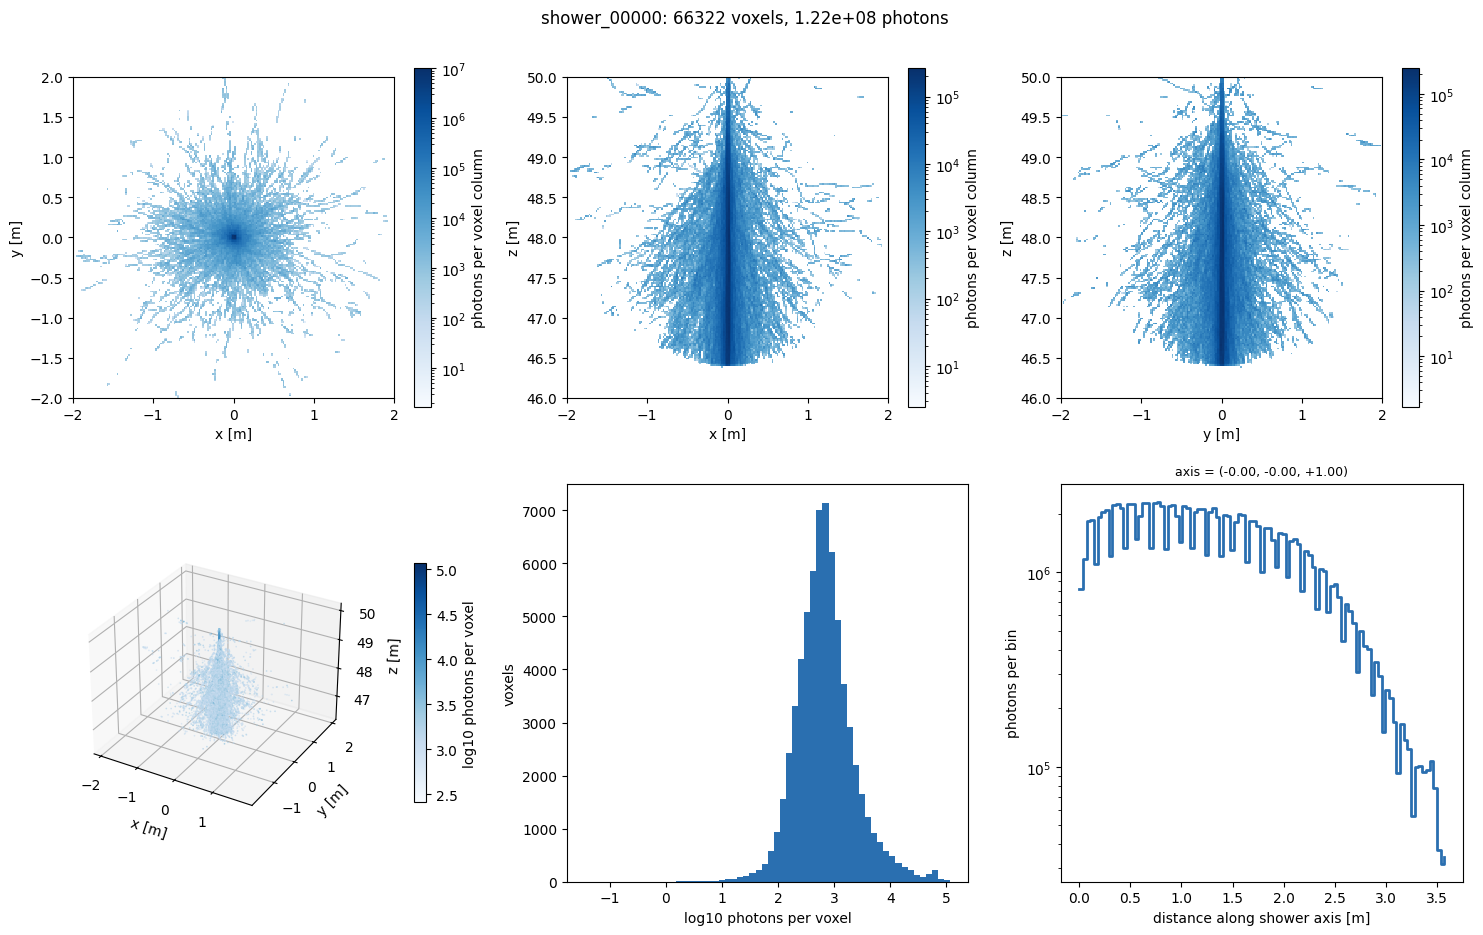

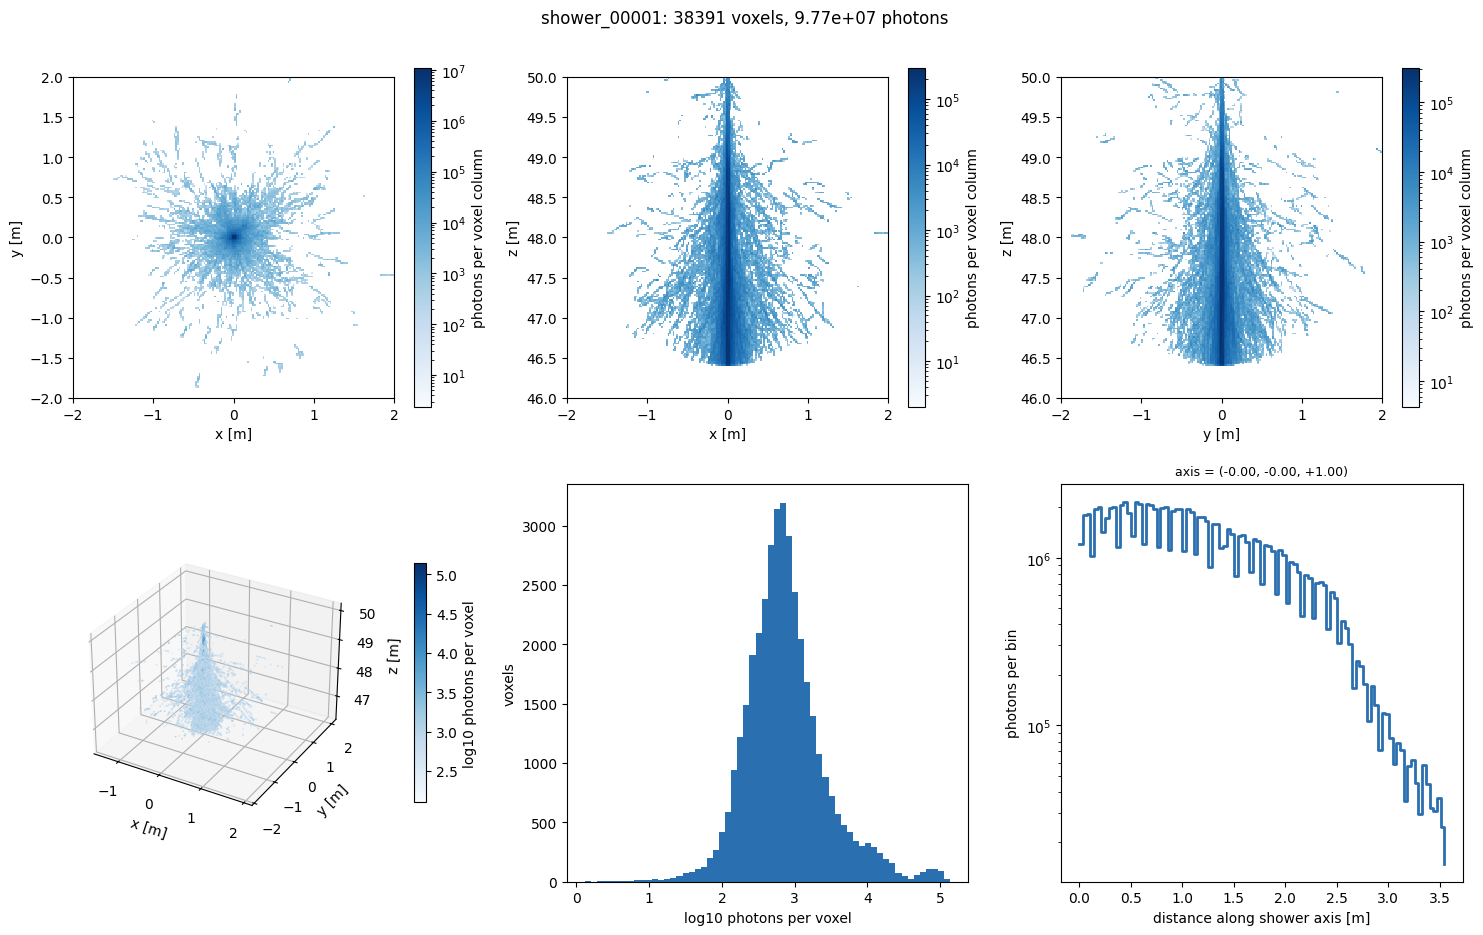

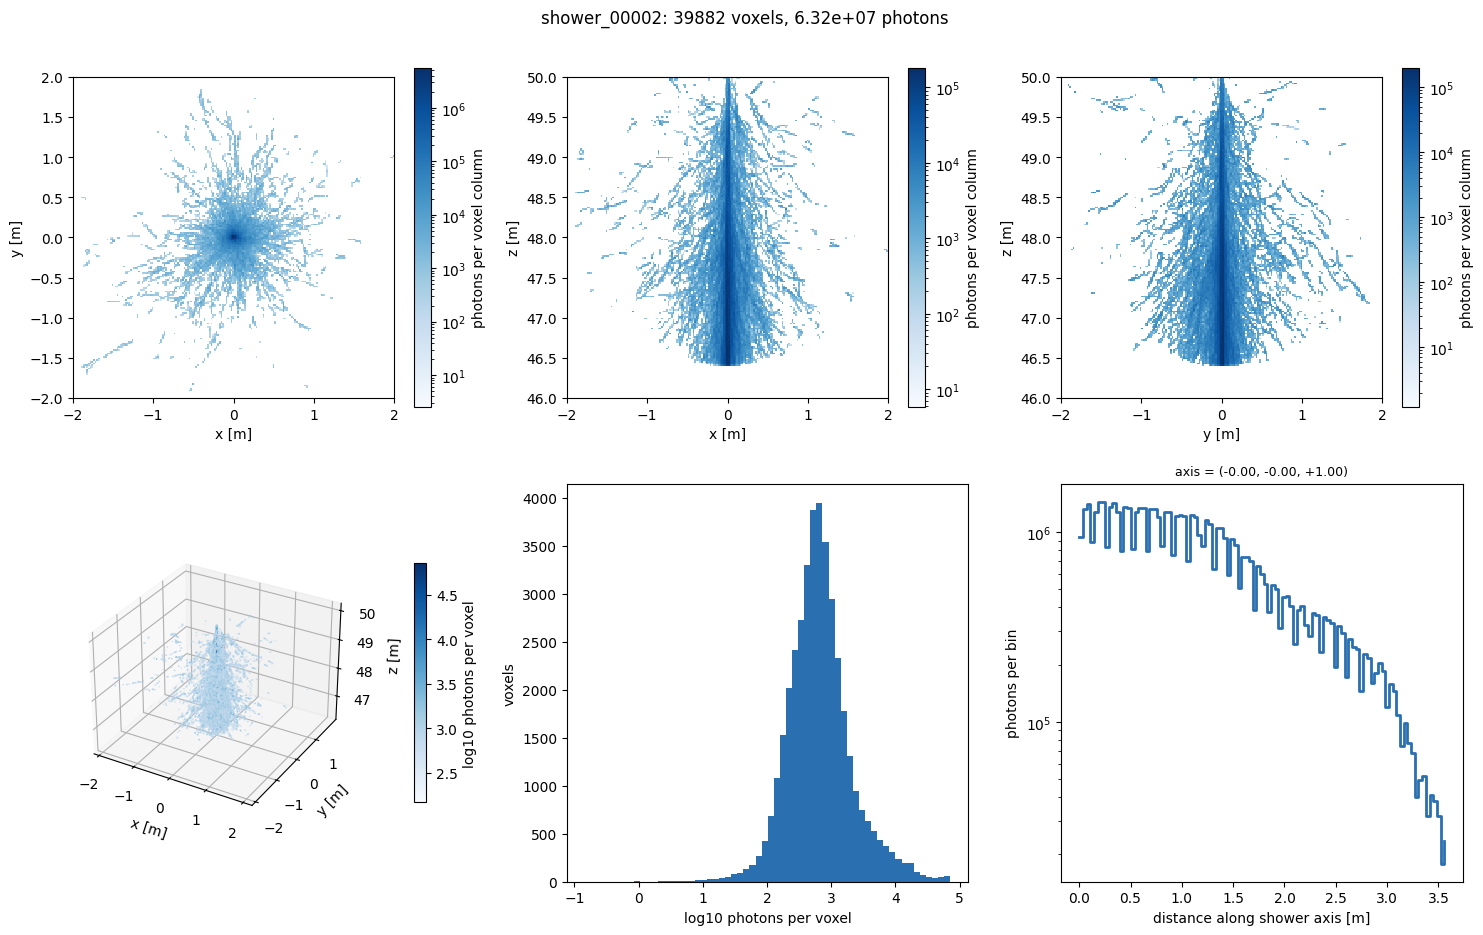

In [3]:
def projection(ax, s, a, b, labels="xyz"):
    box, n = s["box"], 192
    h, _, _ = np.histogram2d(s["xyz"][:, a], s["xyz"][:, b], bins=n,
                             range=[box[a], box[b]], weights=s["q"])
    h = np.ma.masked_equal(h.T, 0)
    im = ax.imshow(h, origin="lower", extent=[*box[a], *box[b]], cmap=CMAP,
                   norm=LogNorm(vmin=max(h.min(), 1e-3), vmax=h.max()), interpolation="nearest")
    ax.set_xlabel(f"{labels[a]} [m]")
    ax.set_ylabel(f"{labels[b]} [m]")
    return im


def axis_profile(s):
    w = s["q"] / s["q"].sum()
    centre = (s["xyz"] * w[:, None]).sum(0)
    d = s["xyz"] - centre
    cov = (d * w[:, None]).T @ d
    axis = np.linalg.eigh(cov)[1][:, -1]
    axis = axis * np.sign(axis[np.abs(axis).argmax()])   # largest component positive
    t = d @ axis
    return t - t.min(), axis


def scatter3d(ax, s):
    keep = np.argsort(s["q"])[::-1][:MAX_POINTS_3D]
    p, q = s["xyz"][keep], s["q"][keep]
    sc = ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=np.log10(q), s=1.5, cmap=CMAP,
                    vmin=np.log10(q).min() - 0.3 * np.ptp(np.log10(q)), linewidths=0)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    return sc


def plot_shower(s):
    fig = plt.figure(figsize=(15, 9.5))
    for k, (a, b) in enumerate([(0, 1), (0, 2), (1, 2)]):
        ax = fig.add_subplot(2, 3, k + 1)
        im = projection(ax, s, a, b)
        fig.colorbar(im, ax=ax, label="photons per voxel column", shrink=0.85)
    ax = fig.add_subplot(2, 3, 4, projection="3d")
    sc = scatter3d(ax, s)
    fig.colorbar(sc, ax=ax, label="log10 photons per voxel", shrink=0.6, pad=0.15)
    ax = fig.add_subplot(2, 3, 5)
    ax.hist(np.log10(s["q"]), bins=60, color="#2a6fb0")
    ax.set_xlabel("log10 photons per voxel")
    ax.set_ylabel("voxels")
    ax = fig.add_subplot(2, 3, 6)
    t, axis = axis_profile(s)
    h, e = np.histogram(t, bins=100, weights=s["q"])
    ax.step(e[:-1], h, where="post", color="#2a6fb0", lw=2)
    ax.set_yscale("log")
    ax.set_xlabel("distance along shower axis [m]")
    ax.set_ylabel("photons per bin")
    ax.set_title(f"axis = ({axis[0]:+.2f}, {axis[1]:+.2f}, {axis[2]:+.2f})", fontsize=9)
    fig.suptitle(f"{s['name']}: {len(s['q'])} voxels, {s['q'].sum():.3g} photons")
    fig.tight_layout()
    plt.show()


for s in showers[:N_DETAIL]:
    plot_shower(s)

## All showers side by side (x-z projection)

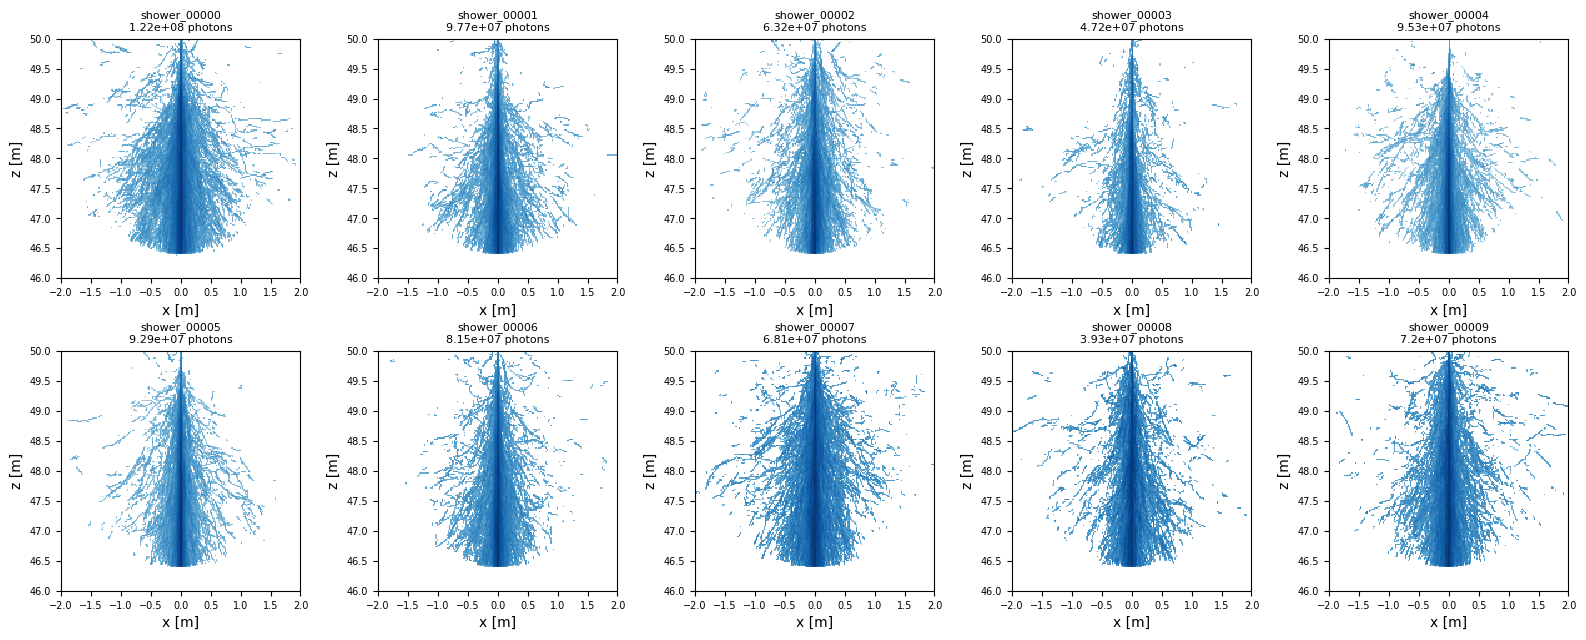

In [4]:
def gallery(showers, a=0, b=2, ncol=5):
    nrow = int(np.ceil(len(showers) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.2 * nrow), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, s in zip(axes.flat, showers):
        ax.axis("on")
        projection(ax, s, a, b)
        ax.set_title(f"{s['name']}\n{s['q'].sum():.3g} photons", fontsize=8)
        ax.tick_params(labelsize=7)
    fig.tight_layout()
    plt.show()


gallery(showers[:40])

## Interactive 3D page

Writes `<SHOWER_DIR>/showers_3d.html` with every shower, in the style of the group-meeting
pages: light accumulated along the line of sight, coloured by log10 photons, all panels
rotating together (drag to rotate, scroll to zoom). Open it in a browser; if Jupyter runs
on the cluster, download the file first. It works offline.

In [5]:
import base64
import html
import json
import time
from pathlib import Path

import numpy as np

# viridis from 0.12 to 1.0, dimmed so that accumulated light saturates softly
VIRIDIS = [(0.2803, 0.1657, 0.4765), (0.2412, 0.2965, 0.5397), (0.1872, 0.4147, 0.5565),
           (0.1448, 0.5191, 0.5566), (0.1201, 0.6222, 0.5349), (0.2140, 0.7221, 0.4696),
           (0.4310, 0.8085, 0.3465), (0.7099, 0.8688, 0.1693), (0.9932, 0.9062, 0.1439)]
LUT_SCALE = 0.6
GRID = 192


def lut256():
    """256-entry viridis colour table used by the page's renderer."""
    a = np.asarray(VIRIDIS)
    t = np.linspace(0, 1, len(a))
    x = np.linspace(0, 1, 256)
    return np.stack([np.interp(x, t, a[:, k]) for k in range(3)], 1) * LUT_SCALE


def build(shower_dir, per_page=6, max_points=250000, title=None):
    """Return the HTML page for every shower_*.npz in shower_dir."""
    d = Path(shower_dir)
    files = sorted(d.glob("shower_*.npz"))
    if not files:
        raise FileNotFoundError(f"no shower_*.npz in {d}")
    run = json.loads((d / "run.json").read_text()) if (d / "run.json").exists() else {}
    raw, rows, box = [], [], None
    for f in files:
        s = np.load(f)
        ijk, q = np.asarray(s["ijk"]), np.asarray(s["nphotons"], dtype=np.float64)
        box = np.asarray(s["box_m"], dtype=np.float64) if box is None else box
        xyz = np.asarray(s["xyz"], dtype=np.float64)
        ext = (xyz.max(0) - xyz.min(0)) if len(xyz) else np.zeros(3)
        rows.append(dict(name=f.stem, n=int(len(q)), q=float(q.sum()), qmax=float(q.max()) if len(q) else 0.0,
                         ext=[round(float(e), 2) for e in ext]))
        raw.append((ijk, np.log10(np.maximum(q, 1e-3))))
    pool = np.concatenate([lq for _, lq in raw])
    lo, hi = float(np.quantile(pool, 0.002)), float(np.quantile(pool, 0.999))
    hi = hi if hi > lo else lo + 1.0
    rng = np.random.default_rng(0)
    for row, (ijk, lq) in zip(rows, raw):
        if max_points and len(lq) > max_points:     # only the drawing is thinned
            keep = np.sort(rng.choice(len(lq), int(max_points), replace=False))
            ijk, lq = ijk[keep], lq[keep]
        a = np.empty((len(lq), 4), dtype=np.uint8)
        a[:, :3] = np.clip(ijk, 0, GRID - 1)
        a[:, 3] = np.clip(np.rint((lq - lo) / (hi - lo) * 255), 0, 255)
        row["b64"], row["drawn"] = base64.b64encode(a.tobytes()).decode(), int(len(a))
    span = box[:, 1] - box[:, 0]
    data = dict(grid=GRID, lut=lut256().round(4).ravel().tolist(), lq_range=[lo, hi], showers=rows,
                per_page=int(per_page), steps=run.get("steps", {}), seed=run.get("seed"),
                geometry=dict(voxel_cm=round(float(span[0] / GRID) * 100, 2), box_m=round(float(span[0]), 2),
                              z=[float(box[2, 0]), float(box[2, 1])]),
                folder=str(d.resolve()), made=time.strftime("%Y-%m-%d %H:%M"))
    page = PAGE.replace("__TITLE__", html.escape(title or "Generated showers"))
    return page.replace("__DATA__", json.dumps(data, separators=(",", ":")).replace("</", "<\\/"))


def write_page(shower_dir, out=None, per_page=6, max_points=250000, title=None):
    """Write the page (default <shower_dir>/showers_3d.html) and return its path."""
    out = Path(out) if out else Path(shower_dir) / "showers_3d.html"
    out.write_text(build(shower_dir, per_page, max_points, title))
    out.chmod(0o644)
    return out


PAGE = r"""<!doctype html>
<html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>__TITLE__</title>
<link rel="preconnect" href="https://fonts.googleapis.com"><link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;500&family=IBM+Plex+Sans+Condensed:wght@500;600&family=IBM+Plex+Sans:wght@400;500;600&display=swap">
<style>
:root{--bg:#f3f5f7;--surface:#fff;--ink:#151a21;--muted:#5d6774;--faint:#8a939e;--rule:#dde2e8;--rule2:#eceff3;--chip:#e8edf3;--screen:#05070a;
--sans:"IBM Plex Sans",system-ui,-apple-system,"Segoe UI",sans-serif;--cond:"IBM Plex Sans Condensed","IBM Plex Sans",system-ui,sans-serif;--mono:"IBM Plex Mono",ui-monospace,"SFMono-Regular",Menlo,Consolas,monospace}
@media (prefers-color-scheme:dark){:root:not([data-theme="light"]){color-scheme:dark;--bg:#0f1216;--surface:#161a20;--ink:#e6e9ee;--muted:#9aa4b1;--faint:#6f7985;--rule:#29303a;--rule2:#1f252d;--chip:#1f262f}}
:root[data-theme="dark"]{color-scheme:dark;--bg:#0f1216;--surface:#161a20;--ink:#e6e9ee;--muted:#9aa4b1;--faint:#6f7985;--rule:#29303a;--rule2:#1f252d;--chip:#1f262f}
*{box-sizing:border-box}body{background:var(--bg);color:var(--ink);font:15px/1.55 var(--sans);margin:0}
.wrap{max-width:1320px;margin:0 auto;padding:28px 20px 56px;display:flex;flex-direction:column;gap:36px}
h1,h2{font-family:var(--cond);font-weight:600;letter-spacing:.005em;margin:0}h1{font-size:clamp(28px,4vw,40px);line-height:1.1}h2{font-size:22px;line-height:1.2}
p{margin:0;max-width:78ch}.eyebrow{font:500 12px/1.4 var(--mono);letter-spacing:.06em;text-transform:uppercase;color:var(--muted)}
.muted{color:var(--muted)}.mono,.num{font-family:var(--mono);font-variant-numeric:tabular-nums}
header{display:flex;flex-direction:column;gap:12px}.facts{display:flex;flex-wrap:wrap;gap:8px}
.chip{font:12.5px/1 var(--mono);background:var(--chip);border-radius:4px;padding:6px 8px;white-space:nowrap}.chip b{font-weight:500;color:var(--muted);margin-right:6px}
section{display:flex;flex-direction:column;gap:16px}.sec-head{display:flex;flex-direction:column;gap:6px}
.tabrow{display:flex;flex-wrap:wrap;gap:6px;align-items:center}.tabrow .lbl{font:500 12px/1 var(--mono);color:var(--muted);text-transform:uppercase;letter-spacing:.05em;margin-right:6px}
.tab{font:500 13px/1 var(--mono);padding:8px 10px;border-radius:5px;border:1px solid var(--rule);background:var(--surface);color:var(--ink);cursor:pointer}
.tab[aria-selected="true"]{background:var(--ink);color:var(--bg);border-color:var(--ink)}
.tab:focus-visible,.btn:focus-visible,input:focus-visible{outline:2px solid #2a78d6;outline-offset:2px}
.controls{display:flex;flex-wrap:wrap;gap:10px 18px;align-items:center;font-size:13px;color:var(--muted)}.controls label{display:flex;gap:8px;align-items:center}
.btn{font:500 12.5px/1 var(--sans);padding:7px 10px;border-radius:5px;border:1px solid var(--rule);background:var(--surface);color:var(--ink);cursor:pointer}
.btn:hover,.tab:hover{border-color:var(--muted)}input[type=range]{width:110px;accent-color:#2a78d6}
.panes{display:grid;grid-template-columns:repeat(auto-fit,minmax(300px,1fr));gap:10px}.pane{display:flex;flex-direction:column;gap:6px}
.screen{position:relative;background:var(--screen);border-radius:6px;overflow:hidden;height:420px;touch-action:none}
.screen canvas{display:block;width:100%;height:100%;cursor:grab}
.pane-head{display:flex;flex-direction:column;gap:2px}.pane-head .name{font:600 14px/1.3 var(--cond)}
.pane-head .meta{font:12px/1.3 var(--mono);color:var(--muted);font-variant-numeric:tabular-nums}
.legend{display:flex;flex-wrap:wrap;gap:14px;font-size:13px;color:var(--muted);align-items:center}
.lut{display:inline-block;width:120px;height:9px;border-radius:2px;vertical-align:-1px}
.tablewrap{overflow-x:auto;background:var(--surface);border:1px solid var(--rule);border-radius:8px}
table{border-collapse:collapse;width:100%;font-size:13.5px}th,td{padding:9px 12px;text-align:right;border-bottom:1px solid var(--rule2);white-space:nowrap}
th:first-child,td:first-child{text-align:left}th{font:600 12px/1.3 var(--sans);letter-spacing:.03em;text-transform:uppercase;color:var(--muted)}
tr.sel td{background:var(--chip)}tbody tr{cursor:pointer}
.notes{display:flex;flex-direction:column;gap:8px;font-size:14px;color:var(--muted)}.notes li{max-width:95ch}
@media (max-width:760px){.screen{height:330px}}
</style></head><body>
<div class="wrap">
<header>
  <div class="eyebrow" id="eyebrow"></div>
  <h1>__TITLE__</h1>
  <p class="muted" id="intro"></p>
  <div class="facts" id="facts"></div>
</header>
<section>
  <div class="sec-head"><h2>3D view</h2><p class="muted">Photon-weighted light, accumulated along the line of sight and coloured by log10 photons per voxel. All panels rotate and zoom together. Drag to rotate, scroll or pinch to zoom.</p></div>
  <div class="tabrow" id="tabs"></div>
  <div class="controls">
    <button class="btn" id="v-side">Side x–z</button><button class="btn" id="v-side2">Side y–z</button><button class="btn" id="v-top">Top x–y</button><button class="btn" id="v-reset">Reset</button>
    <label><input type="checkbox" id="spin"> Rotate</label>
    <label for="qmin">Min photons <input type="range" id="qmin" min="0" max="250" value="0"></label>
    <label for="gain">Gain <input type="range" id="gain" min="2" max="80" value="18"></label>
    <label for="psize">Point <input type="range" id="psize" min="1" max="4" value="2"></label>
  </div>
  <div class="panes" id="panes"></div>
  <div class="legend"><span>log10 photons</span><span class="mono" id="lq-lo"></span><span class="lut" id="lut"></span><span class="mono" id="lq-hi"></span><span id="boxnote"></span></div>
</section>
<section>
  <div class="sec-head"><h2>Every shower</h2><p class="muted">Click a row to show its page above.</p></div>
  <div class="tablewrap"><table id="tall"></table></div>
</section>
<section>
  <h2>How this page was made</h2>
  <ul class="notes" id="notes"></ul>
</section>
</div>
<script>
const D=__DATA__;
const $=id=>document.getElementById(id);
const sci=v=>{if(v==null||!v)return '–';const e=Math.floor(Math.log10(Math.abs(v)));return (v/10**e).toFixed(2)+'e'+e;};
const G=D.grid,GEO=D.geometry,S=D.showers,PP=D.per_page,NP=Math.ceil(S.length/PP);
$('eyebrow').textContent=`CORSIKA 8 in-ice Cherenkov · ${G}³ voxels of ${GEO.voxel_cm} cm · z ${GEO.z[0]}–${GEO.z[1]} m · generated, 1 TeV`;
$('intro').textContent=`${S.length} generated showers from ${D.folder}. Each is a new sample from the trained model; none is paired with a simulated event.`;
const chips=[];const st=D.steps||{};if(Object.keys(st).length)chips.push(`<span class="chip"><b>model steps</b>${Object.entries(st).map(([k,v])=>k+' '+Number(v).toLocaleString()).join(' · ')}</span>`);
if(D.seed!=null)chips.push(`<span class="chip"><b>seed</b>${D.seed}</span>`);
const nv=S.map(s=>s.n).sort((a,b)=>a-b),qv=S.map(s=>s.q).sort((a,b)=>a-b),med=a=>a[Math.floor(a.length/2)];
chips.push(`<span class="chip"><b>median voxels</b>${med(nv).toLocaleString()}</span>`,`<span class="chip"><b>median photons</b>${sci(med(qv))}</span>`,`<span class="chip"><b>made</b>${D.made}</span>`);
$('facts').innerHTML=chips.join('');
const LUT=D.lut;$('lq-lo').textContent=D.lq_range[0].toFixed(1);$('lq-hi').textContent=D.lq_range[1].toFixed(1);
$('boxnote').textContent=`· box ${GEO.box_m} m on a side, axes x red, y green, z blue`;
$('lut').style.background='linear-gradient(90deg,'+[0,64,128,192,255].map(i=>`rgb(${[0,1,2].map(k=>Math.round(255*Math.min(1,LUT[3*i+k]/0.6))).join(',')})`).join(',')+')';
function dec(b){const s=atob(b),a=new Uint8Array(s.length);for(let i=0;i<s.length;i++)a[i]=s.charCodeAt(i);return a;}
const V={yaw:-0.6,pitch:0.3,zoom:1};let panes=[],page=0;
function build(pg){page=pg;const box=$('panes');box.innerHTML='';
  document.querySelectorAll('.tab').forEach(b=>b.setAttribute('aria-selected',+b.dataset.p===pg?'true':'false'));
  document.querySelectorAll('#tall tbody tr').forEach(r=>r.classList.toggle('sel',Math.floor(+r.dataset.i/PP)===pg));
  panes=S.slice(pg*PP,(pg+1)*PP).map(s=>{const d=document.createElement('div');d.className='pane';
    d.innerHTML=`<div class="pane-head"><span class="name">${s.name}</span><span class="meta">${s.n.toLocaleString()} voxels · ${sci(s.q)} photons${s.drawn<s.n?' · drawing '+s.drawn.toLocaleString():''}</span></div><div class="screen"></div>`;
    box.appendChild(d);const sc=d.querySelector('.screen'),cv=document.createElement('canvas');sc.appendChild(cv);bind(cv);const data=dec(s.b64);return {cv,sc,data,n:data.length/4};});
  size();}
function size(){panes.forEach(p=>{const r=p.sc.getBoundingClientRect(),dpr=Math.min(2,window.devicePixelRatio||1);p.cv.width=Math.round(r.width*dpr);p.cv.height=Math.round(r.height*dpr);p.dpr=dpr;});draw();}
function draw(){const qmin=+$('qmin').value,gain=+$('gain').value/10,sz=+$('psize').value;
  const cy=Math.cos(V.yaw),sy=Math.sin(V.yaw),cp=Math.cos(V.pitch),sp=Math.sin(V.pitch),h=G/2;
  for(const p of panes){const W=p.cv.width,H=p.cv.height,ctx=p.cv.getContext('2d'),dp=p.dpr,ps=Math.max(1,Math.round(sz*dp/1.5*Math.max(1,192/G)));
    const sc=V.zoom*Math.min(W,H)/(G*1.85),buf=new Float32Array(W*H*3),d=p.data;
    for(let i=0;i<p.n;i++){const o=4*i,ci=d[o+3];if(ci<qmin)continue;
      const x=d[o]-h,y=d[o+1]-h,z=d[o+2]-h,x1=x*cy-y*sy,y1=x*sy+y*cy,z2=y1*sp+z*cp;
      const u=(W/2+x1*sc)|0,v=(H/2-z2*sc)|0,r=LUT[3*ci],g=LUT[3*ci+1],b=LUT[3*ci+2];
      for(let a=0;a<ps;a++)for(let c=0;c<ps;c++){const uu=u+a,vv=v+c;if(uu<0||vv<0||uu>=W||vv>=H)continue;const k=3*(vv*W+uu);buf[k]+=r;buf[k+1]+=g;buf[k+2]+=b;}}
    const img=ctx.createImageData(W,H),px=img.data;
    for(let k=0,j=0;k<buf.length;k+=3,j+=4){px[j]=5+250*(1-Math.exp(-gain*buf[k]));px[j+1]=7+248*(1-Math.exp(-gain*buf[k+1]));px[j+2]=10+245*(1-Math.exp(-gain*buf[k+2]));px[j+3]=255;}
    ctx.putImageData(img,0,0);
    const P=(x,y,z)=>{x-=h;y-=h;z-=h;const x1=x*cy-y*sy,y1=x*sy+y*cy,z2=y1*sp+z*cp;return [W/2+x1*sc,H/2-z2*sc];};
    ctx.strokeStyle='rgba(160,172,188,0.35)';ctx.lineWidth=dp;ctx.beginPath();
    const E=[[0,0,0,G,0,0],[0,G,0,G,G,0],[0,0,G,G,0,G],[0,G,G,G,G,G],[0,0,0,0,G,0],[G,0,0,G,G,0],[0,0,G,0,G,G],[G,0,G,G,G,G],[0,0,0,0,0,G],[G,0,0,G,0,G],[0,G,0,0,G,G],[G,G,0,G,G,G]];
    for(const e of E){const a=P(e[0],e[1],e[2]),b=P(e[3],e[4],e[5]);ctx.moveTo(a[0],a[1]);ctx.lineTo(b[0],b[1]);}ctx.stroke();
    ctx.font=`${12*dp}px ui-monospace,monospace`;const o0=P(0,0,0);
    for(const [l,x,y,z,c] of [['x',G*1.1,0,0,'#e66767'],['y',0,G*1.1,0,'#3fbf8a'],['z',0,0,G*1.1,'#5b9cf0']]){const q=P(x,y,z);
      ctx.strokeStyle=c;ctx.fillStyle=c;ctx.lineWidth=2*dp;ctx.beginPath();ctx.moveTo(o0[0],o0[1]);ctx.lineTo(q[0],q[1]);ctx.stroke();ctx.fillText(l,q[0]+4*dp,q[1]-4*dp);}}}
let drag=null;
function bind(cv){cv.addEventListener('pointerdown',e=>{drag=[e.clientX,e.clientY];cv.setPointerCapture(e.pointerId);});
  cv.addEventListener('pointermove',e=>{if(!drag)return;V.yaw+=(e.clientX-drag[0])*0.008;V.pitch=Math.max(-1.57,Math.min(1.57,V.pitch+(e.clientY-drag[1])*0.008));drag=[e.clientX,e.clientY];draw();});
  cv.addEventListener('pointerup',()=>drag=null);cv.addEventListener('pointercancel',()=>drag=null);
  cv.addEventListener('wheel',e=>{e.preventDefault();V.zoom=Math.max(0.4,Math.min(6,V.zoom*Math.exp(-e.deltaY*0.001)));draw();},{passive:false});}
const setV=(y,p)=>{V.yaw=y;V.pitch=p;draw();};
$('v-side').onclick=()=>setV(0,0);$('v-side2').onclick=()=>setV(-Math.PI/2,0);$('v-top').onclick=()=>setV(0,Math.PI/2);$('v-reset').onclick=()=>{V.zoom=1;setV(-0.6,0.3);};
['qmin','gain','psize'].forEach(i=>$(i).addEventListener('input',draw));
const reduce=matchMedia('(prefers-reduced-motion: reduce)').matches;
(function tick(){if($('spin').checked&&!reduce){V.yaw+=0.01;draw();}requestAnimationFrame(tick);})();
$('tabs').innerHTML=NP>1?'<span class="lbl">Showers</span>'+Array.from({length:NP},(_,p)=>`<button class="tab" role="tab" data-p="${p}">${p*PP+1===Math.min(S.length,(p+1)*PP)?p*PP+1:(p*PP+1)+'–'+Math.min(S.length,(p+1)*PP)}</button>`).join(''):'';
document.querySelectorAll('.tab').forEach(b=>b.onclick=()=>build(+b.dataset.p));
let t=`<thead><tr><th>Shower</th><th>Voxels</th><th>Photons</th><th>Max per voxel</th><th>Extent x, y, z [m]</th></tr></thead><tbody>`;
S.forEach((s,i)=>{t+=`<tr data-i="${i}"><td>${s.name}</td><td class="num">${s.n.toLocaleString()}</td><td class="num">${sci(s.q)}</td><td class="num">${sci(s.qmax)}</td><td class="num">${s.ext.map(v=>v.toFixed(2)).join(', ')}</td></tr>`;});
$('tall').innerHTML=t+'</tbody>';
document.querySelectorAll('#tall tbody tr').forEach(r=>r.onclick=()=>{build(Math.floor(+r.dataset.i/PP));window.scrollTo({top:0,behavior:'smooth'});});
$('notes').innerHTML=[`Source: the <span class="mono">shower_*.npz</span> files written by <span class="mono">generate.py</span>; model steps and seed from <span class="mono">run.json</span>.`,
 `The panels draw voxel centres on the ${G}³ grid. Colour scale: log10 photons from the 0.2% to the 99.9% quantile of all showers on this page, so colours are comparable between panels.`,
 `"Min photons" hides voxels below a colour level; "Gain" sets how fast accumulated light saturates.`].map(t=>`<li>${t}</li>`).join('');
let rt;window.addEventListener('resize',()=>{clearTimeout(rt);rt=setTimeout(size,120);});
build(0);
</script></body></html>
"""


print("wrote", write_page(SHOWER_DIR, per_page=6))

wrote showers/showers_3d.html
